## Segmentation Visualization with OpenCV

### Imports

In [ ]:
import cv2                        # OpenCV is a library of programming functions mainly aimed at real-time computer vision.   
import matplotlib.pyplot as plt

```  
Import	                Purpose	             What it gives us
cv2	                OpenCV library	     Read images, convert color spaces, apply thresholding
matplotlib.pyplot	Plotting library     Display images, create subplots, visualize results

Why these?
OpenCV is the industry standard for image processing
Matplotlib gives us nice visualization capabilities
Together, they let us understand segmentation concepts visually before diving into deep learning



### Load image

(np.float64(-0.5), np.float64(2939.5), np.float64(1959.5), np.float64(-0.5))

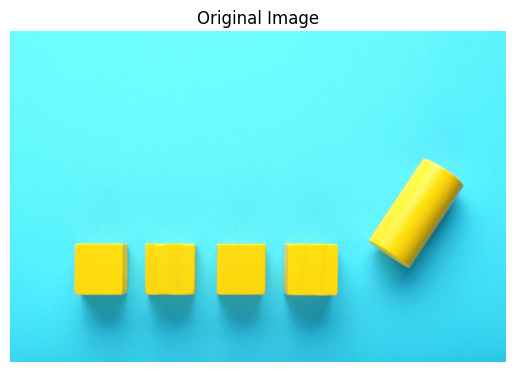

In [29]:
img = cv2.imread("sample.png")             # read image from file and store it in a variable as a numpy array of pixel values          
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)                            # display the numpy array of the pixel values from the image in order of red, green, blue (RGB) color channels
plt.title("Original Image")
plt.axis("off")

```
img = cv2.imread("sample.jpg")
What cv2.imread() does:

Reads the image file from disk
Decodes the image format (JPEG, PNG, etc.)
Returns a NumPy array of pixel values
Default behavior:
OpenCV reads images in BGR format (Blue-Green-Red order)
This is a historical artifact from early camera hardware
Shape: (height, width, 3) for color images
Values: 0-255 (uint8)
If image not found: Returns None (will cause errors later)

python
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

Why color conversion is necessary:
The problem:
OpenCV reads as BGR:  [Blue, Green, Red]
Matplotlib expects:   [Red, Green, Blue]

If we don't convert:
- Red channel becomes Blue
- Blue channel becomes Red
- Image looks wrong (blue tint)

What cvtColor does:
Reorders the color channels
COLOR_BGR2RGB swaps the first and third channels

Keeps all pixel values the same, just rearranged
Visual example:
Before conversion (BGR):
Pixel = [150, 100, 50]  # Blue=150, Green=100, Red=50
After conversion (RGB):
Pixel = [50, 100, 150]   # Red=50, Green=100, Blue=150


### Convert to grayscale

(np.float64(-0.5), np.float64(2939.5), np.float64(1959.5), np.float64(-0.5))

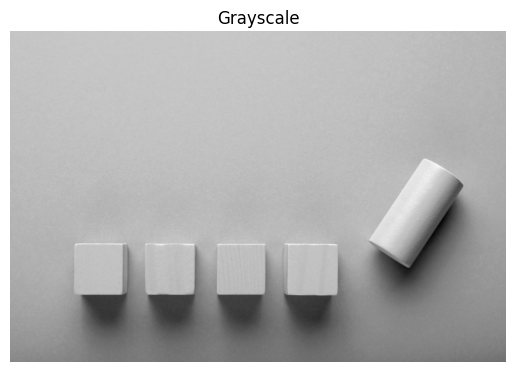

In [30]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)     # convert image to grayscale for simplicity

plt.imshow(gray, cmap="gray")                    # cmap="gray" tells matplotlib to use a grayscale colormap  
plt.title("Grayscale")
plt.axis("off")

```
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

Why convert to grayscale?
For segmentation demonstration:
Simpler to understand (1 channel instead of 3)
Thresholding works on single intensity values
Many segmentation tasks start with grayscale (medical images, etc.)

What happens mathematically:

Grayscale = 0.299 × R + 0.587 × G + 0.114 × B
(Weighted sum based on human perception)

Example RGB pixel [100, 150, 200]:
Gray = 0.299×100 + 0.587×150 + 0.114×200
     = 29.9 + 88.05 + 22.8
     = 140.75 ≈ 141
Before conversion: Shape (H, W, 3) - 3 values per pixel
After conversion: Shape (H, W) - 1 value per pixel (intensity)

### Simple segmentation mask

(np.float64(-0.5), np.float64(2939.5), np.float64(1959.5), np.float64(-0.5))

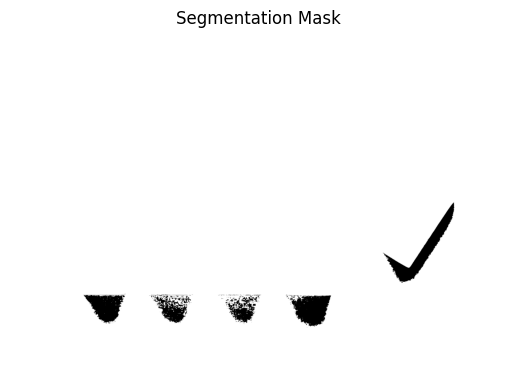

In [31]:
_, mask = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)   # 255: white, 0: black
plt.imshow(mask, cmap="gray")      
plt.title("Segmentation Mask")
plt.axis("off")

```
_, mask = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)
What is thresholding?
Definition: Thresholding converts a grayscale image to binary (black:0 and white:1) based on a cutoff value.

Parameters explained:
Parameter	        Value	            Meaning
gray	-	        Input               grayscale image
120	                threshold value	    Cutoff point (pixels above/below this)
255	                max value	        Value to assign to pixels passing threshold
cv2.THRESH_BINARY	type	            Binary thresholding method

How thresholding works:
For each pixel in the image:

if pixel_value > 120:
    new_value = 255 (white)
else:
    new_value = 0 (black)

The _ (underscore):
cv2.threshold returns two values: (retval, thresholded_image)
retval is the actual threshold used (same as 120 in simple case)
We don't need it, so we use _ to ignore it

Visual example:
Grayscale values:   [45,  132, 78,  201, 56, 189]
                     │    │    │    │    │    │
Threshold (120):     ▼    ▼    ▼    ▼    ▼    ▼
                    [0,  255,   0, 255,  0, 255]
                    
Result mask:        black, white, black, white, black, white

python
plt.imshow(mask, cmap="gray")
plt.title("Segmentation Mask")
plt.axis("off")

What the mask shows:
White pixels (255): Regions above threshold
Black pixels (0): Regions below threshold
This is a SIMPLE segmentation:
Each pixel classified into one of two classes
Creates a binary mask
Exactly what deep learning segmentation does, but with learned thresholds per pixel!



### Overlay mask

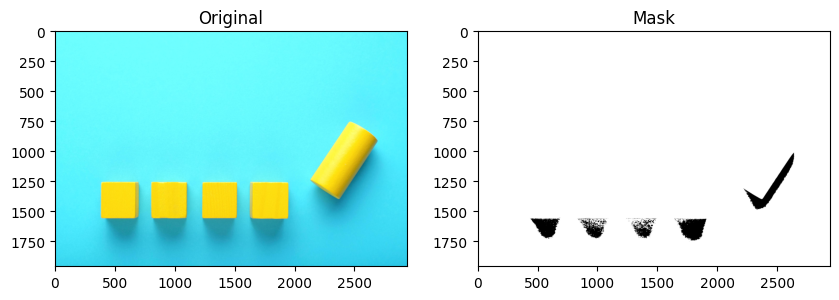

In [ ]:
plt.figure(figsize=(10,5))            # create a new figure with a specified size to display the original image and the mask side by side, 10 inches wide and 5 inches tall

plt.subplot(1,2,1)                    # create a subplot with 1 row and 2 columns, and set the current subplot to the first one (the original image) for displaying the original image and the mask side by side
plt.imshow(img)
plt.title("Original")

plt.subplot(1,2,2)                   
plt.title("Mask")

plt.show()